# Tabular Benchmarks - UNSW-NB15 and Synthetic IPv6

Classical and paper-inspired tabular baselines for binary and multiclass IDS evaluation.


In [ ]:
import json
import math
import random
import zipfile
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
)

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

GLOBAL_SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything(GLOBAL_SEED)

OUTPUT_ROOT = Path("benchmark_artifacts")
UNSW_OUT = OUTPUT_ROOT / "unsw"
SYN_OUT = OUTPUT_ROOT / "synthetic"
COMBINED_OUT = OUTPUT_ROOT / "combined"

for base in [UNSW_OUT, SYN_OUT, COMBINED_OUT]:
    for sub in [base / "multiclass", base / "binary"]:
        (sub / "tables").mkdir(parents=True, exist_ok=True)
        (sub / "figures").mkdir(parents=True, exist_ok=True)
        (sub / "metrics").mkdir(parents=True, exist_ok=True)
        (sub / "reports").mkdir(parents=True, exist_ok=True)

COMBINED_OUT.mkdir(parents=True, exist_ok=True)

USE_HF_DOWNLOAD = False
UNSW_TRAIN_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_training-set.csv"
UNSW_TEST_CSV = "/kaggle/input/datasets/mrwellsdavid/unsw-nb15/UNSW_NB15_testing-set.csv"


SYN_ROOT = "/kaggle/input/datasets/synthetic-data/synthetic_ipv6_grounded_v3_32x32"

SEEDS = [11, 22, 33, 44, 55]
TRAIN_FRACTION_PER_SEED = 0.85
UNSTABLE_SUPPORT_THRESHOLD = 5

print("xgboost available:", HAS_XGB)
print("Output root:", OUTPUT_ROOT.resolve())


xgboost available: True
Output root: /kaggle/working/benchmark_artifacts


## Dataset Loading

UNSW-NB15 uses the official train/test split. The synthetic IPv6 dataset uses the provided train, validation, and test split files.


In [2]:
if USE_HF_DOWNLOAD:
    from huggingface_hub import hf_hub_download
    HF_REPO = "Mouwiya/UNSW-NB15-small"
    UNSW_TRAIN_CSV = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_training-set.csv", repo_type="dataset")
    UNSW_TEST_CSV  = hf_hub_download(repo_id=HF_REPO, filename="UNSW_NB15_testing-set.csv", repo_type="dataset")

unsw_train = pd.read_csv(UNSW_TRAIN_CSV)
unsw_test  = pd.read_csv(UNSW_TEST_CSV)


syn_flows = pd.read_csv(f"{SYN_ROOT}/flows.csv")
syn_train_split = pd.read_csv(f"{SYN_ROOT}/train.csv")
syn_val_split   = pd.read_csv(f"{SYN_ROOT}/val.csv")
syn_test_split  = pd.read_csv(f"{SYN_ROOT}/test.csv")

syn_train = syn_flows.merge(syn_train_split[["record_id"]], on="record_id", how="inner")
syn_val   = syn_flows.merge(syn_val_split[["record_id"]],   on="record_id", how="inner")
syn_test  = syn_flows.merge(syn_test_split[["record_id"]],  on="record_id", how="inner")

print("UNSW shapes:", unsw_train.shape, unsw_test.shape)
print("Synthetic split sizes:", {"train": len(syn_train), "val": len(syn_val), "test": len(syn_test), "total": len(syn_flows)})

display(unsw_train.head(2))
display(syn_flows.head(2))


UNSW shapes: (82332, 45) (175341, 45)
Synthetic split sizes: {'train': 2100, 'val': 450, 'test': 450, 'total': 3000}


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0


,record_id,label,window_start_utc,window_end_utc,ip_version,src_ip,dst_ip,src_port,dst_port,transport,...,tcp_ack,tcp_fin,tcp_rst,ipv6_flow_label,ipv6_next_header,ipv6_hop_limit,ipv6_ext_hdr_count,ipv6_fragment_count,icmpv6_nd_msgs,payload_entropy
0,R0000001,Benign,2026-01-01T03:42:04+00:00,2026-01-01T03:42:04.265000+00:00,6,2001:db8:1:ae00:2f8c:83e5:6e8d:9644,2001:db8:1:614c:a921:cb4c:95fb:e976,51628,80,TCP,...,4,0,0,172046,6,122,2,1,0,3.475082
1,R0000002,Benign,2026-01-01T03:10:48+00:00,2026-01-01T03:10:48.243000+00:00,6,2001:db8:1:5111:63be:441d:bd5a:c9e,2001:db8:117:6de2:1b46:ebdc:5c56:d9bc,62821,443,UDP,...,0,0,0,214394,17,132,1,1,1,4.974224


## Dataset Audit

Split integrity checks, label distributions, support tables, and low-support class flags.


Synthetic overlap counts: {'train_val': 0, 'train_test': 0, 'val_test': 0}


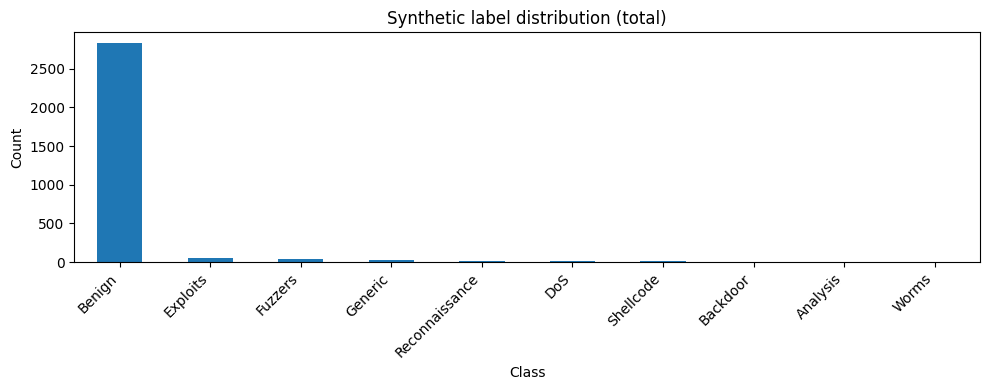

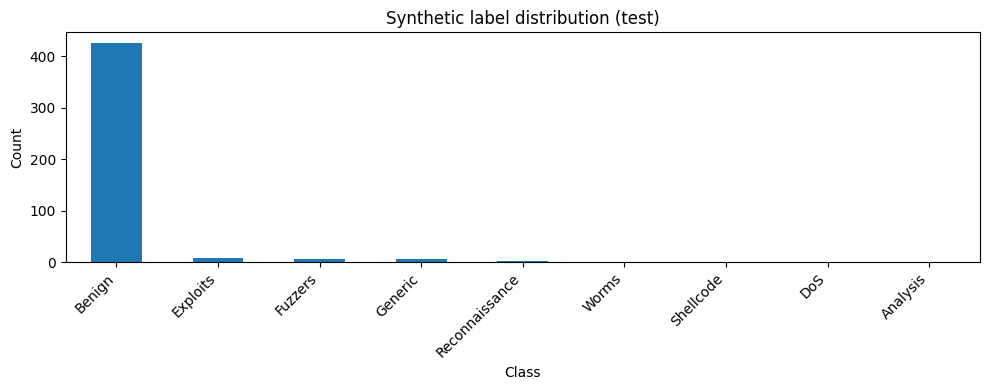

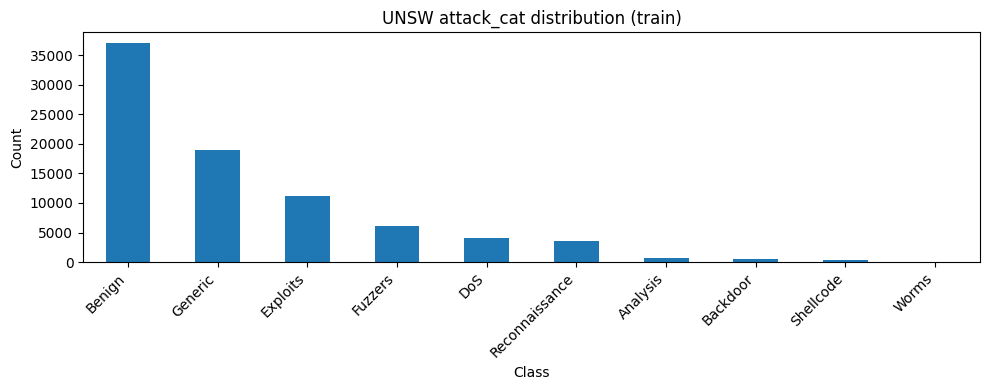

,label,support,unstable
0,Shellcode,1,True
1,DoS,1,True
2,Worms,1,True
3,Analysis,1,True
4,Reconnaissance,3,True
5,Generic,5,False
6,Fuzzers,6,False
7,Exploits,7,False
8,Benign,425,False


,label,support,unstable
0,Worms,130,False
1,Shellcode,1133,False
2,Backdoor,1746,False
3,Analysis,2000,False
4,Reconnaissance,10491,False
5,DoS,12264,False
6,Fuzzers,18184,False
7,Exploits,33393,False
8,Generic,40000,False
9,Benign,56000,False


In [3]:
def normalize_attack_name(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip()
    if s.lower() == "normal":
        return "Benign"
    return s

def support_flag_table(labels, threshold=5):
    vc = pd.Series(labels).value_counts().sort_values(ascending=True)
    out = vc.rename_axis("label").reset_index(name="support")
    out["unstable"] = out["support"] < threshold
    return out

def check_overlap(a, b, key="record_id"):
    return len(set(a[key]).intersection(set(b[key])))

def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))

def save_text(txt, path):
    Path(path).write_text(str(txt))

def plot_bar(series, title, xlabel, ylabel, save_path, top_k=None):
    s = series.copy()
    if top_k is not None:
        s = s.head(top_k)
    plt.figure(figsize=(10, 4))
    s.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_confusion(cm, labels, title, save_path, max_labels=20):
    show_labels = labels[:max_labels]
    show_cm = np.array(cm)[:max_labels, :max_labels]
    plt.figure(figsize=(8, 6))
    plt.imshow(show_cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    ticks = np.arange(len(show_labels))
    plt.xticks(ticks, show_labels, rotation=45, ha="right")
    plt.yticks(ticks, show_labels)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

syn_overlap = {
    "train_val": check_overlap(syn_train, syn_val),
    "train_test": check_overlap(syn_train, syn_test),
    "val_test": check_overlap(syn_val, syn_test),
}
print("Synthetic overlap counts:", syn_overlap)

save_json(syn_overlap, SYN_OUT / "multiclass" / "metrics" / "split_overlap.json")
save_json(syn_overlap, SYN_OUT / "binary" / "metrics" / "split_overlap.json")

plot_bar(
    syn_flows["label"].value_counts().sort_values(ascending=False),
    "Synthetic label distribution (total)", "Class", "Count",
    SYN_OUT / "multiclass" / "figures" / "synthetic_label_distribution_total.png", top_k=15
)

plot_bar(
    syn_test["label"].value_counts().sort_values(ascending=False),
    "Synthetic label distribution (test)", "Class", "Count",
    SYN_OUT / "multiclass" / "figures" / "synthetic_label_distribution_test.png", top_k=15
)

plot_bar(
    unsw_train["attack_cat"].apply(normalize_attack_name).value_counts().sort_values(ascending=False),
    "UNSW attack_cat distribution (train)", "Class", "Count",
    UNSW_OUT / "multiclass" / "figures" / "unsw_attackcat_distribution_train.png", top_k=15
)

syn_support_mc = support_flag_table(syn_test["label"], threshold=UNSTABLE_SUPPORT_THRESHOLD)
unsw_support_mc = support_flag_table(unsw_test["attack_cat"].apply(normalize_attack_name), threshold=UNSTABLE_SUPPORT_THRESHOLD)

syn_support_mc.to_csv(SYN_OUT / "multiclass" / "tables" / "test_support_flags.csv", index=False)
unsw_support_mc.to_csv(UNSW_OUT / "multiclass" / "tables" / "test_support_flags.csv", index=False)

display(syn_support_mc.head(15))
display(unsw_support_mc.head(15))


## Task Definitions

Binary and multiclass task adapters for UNSW-NB15 and synthetic IPv6.


In [4]:
def prepare_unsw_task(task="multiclass"):
    df_train = unsw_train.copy()
    df_test = unsw_test.copy()

    if task == "multiclass":
        target = "attack_cat"
        df_train[target] = df_train[target].apply(normalize_attack_name)
        df_test[target]  = df_test[target].apply(normalize_attack_name)
        drop_cols = ["id", "label"]
        labels = sorted(pd.Series(df_train[target]).unique().tolist())
    else:
        target = "label"
        df_train[target] = df_train[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        df_test[target]  = df_test[target].astype(str).map(lambda x: "Attack" if str(x) == "1" else "Benign")
        drop_cols = ["id", "attack_cat"]
        labels = ["Benign", "Attack"]

    X_train = df_train.drop(columns=[target] + drop_cols, errors="ignore")
    y_train = df_train[target].astype(str).values
    X_test = df_test.drop(columns=[target] + drop_cols, errors="ignore")
    y_test = df_test[target].astype(str).values

    return {
        "X_pool": X_train.reset_index(drop=True),
        "y_pool": y_train,
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test,
        "labels": labels,
        "dataset_name": "unsw",
        "task": task,
    }

def prepare_synthetic_task(task="multiclass"):
    df_pool = pd.concat([syn_train, syn_val], axis=0).reset_index(drop=True)
    df_test = syn_test.copy()

    if task == "multiclass":
        target = "label"
        labels = sorted(pd.Series(df_pool[target]).unique().tolist())
    else:
        target = "label"
        df_pool[target] = df_pool[target].astype(str).map(lambda x: "Benign" if str(x) == "Benign" else "Attack")
        df_test[target] = df_test[target].astype(str).map(lambda x: "Benign" if str(x) == "Benign" else "Attack")
        labels = ["Benign", "Attack"]

    drop_cols = ["record_id", "window_start_utc", "window_end_utc", "src_ip", "dst_ip"]

    X_pool = df_pool.drop(columns=[target] + drop_cols, errors="ignore")
    y_pool = df_pool[target].astype(str).values
    X_test = df_test.drop(columns=[target] + drop_cols, errors="ignore")
    y_test = df_test[target].astype(str).values

    return {
        "X_pool": X_pool.reset_index(drop=True),
        "y_pool": y_pool,
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test,
        "labels": labels,
        "dataset_name": "synthetic",
        "task": task,
    }

unsw_mc = prepare_unsw_task("multiclass")
unsw_bin = prepare_unsw_task("binary")
syn_mc = prepare_synthetic_task("multiclass")
syn_bin = prepare_synthetic_task("binary")

print("UNSW multiclass pool/test:", unsw_mc["X_pool"].shape, unsw_mc["X_test"].shape)
print("Synthetic multiclass pool/test:", syn_mc["X_pool"].shape, syn_mc["X_test"].shape)


UNSW multiclass pool/test: (82332, 42) (175341, 42)
Synthetic multiclass pool/test: (2550, 22) (450, 22)


## Preprocessing

Linear and tree-compatible preprocessing pipelines.


In [5]:
def build_preprocessors(X_pool: pd.DataFrame):
    cat_cols = [c for c in X_pool.columns if X_pool[c].dtype == "object"]
    num_cols = [c for c in X_pool.columns if c not in cat_cols]

    preprocess_linear = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler(with_mean=False)),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop"
    )

    preprocess_tree = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]), cat_cols),
        ],
        remainder="drop"
    )

    return preprocess_linear, preprocess_tree, num_cols, cat_cols

def multiclass_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", labels=labels, zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", labels=labels, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0, digits=4)
    return {
        "accuracy": float(acc),
        "macro_precision": float(p_macro),
        "macro_recall": float(r_macro),
        "macro_f1": float(f1_macro),
        "weighted_precision": float(p_weighted),
        "weighted_recall": float(r_weighted),
        "weighted_f1": float(f1_weighted),
        "confusion_matrix": cm.tolist(),
        "report": report,
    }

def binary_metrics(y_true, y_pred, positive_label="Attack"):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=positive_label, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=["Benign", "Attack"])
    report = classification_report(y_true, y_pred, labels=["Benign", "Attack"], digits=4, zero_division=0)
    return {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "confusion_matrix": cm.tolist(),
        "report": report,
    }


## Model Suite

Core tabular baselines and paper-inspired benchmark models.


In [6]:
def build_core_models(seed, preprocess_linear, preprocess_tree):
    models = {
        "core_lr": Pipeline([
            ("prep", preprocess_linear),
            ("clf", LogisticRegression(
                max_iter=5000, solver="saga", class_weight="balanced",
                multi_class="auto", random_state=seed
            ))
        ]),
        "core_linearsvc": Pipeline([
            ("prep", preprocess_linear),
            ("clf", LinearSVC(class_weight="balanced", random_state=seed))
        ]),
        "core_rf": Pipeline([
            ("prep", preprocess_tree),
            ("clf", RandomForestClassifier(
                n_estimators=300, random_state=seed, n_jobs=-1,
                class_weight="balanced_subsample"
            ))
        ]),
        "core_hgb": Pipeline([
            ("prep", preprocess_tree),
            ("clf", HistGradientBoostingClassifier(random_state=seed))
        ]),
    }
    return models

def build_more2024_fixed_models(seed, preprocess_linear, preprocess_tree):
    models = {
        "more2024_rf_gini_d22_s6_n300": Pipeline([
            ("prep", preprocess_tree),
            ("clf", RandomForestClassifier(
                criterion="gini",
                max_depth=22,
                min_samples_split=6,
                n_estimators=300,
                n_jobs=-1,
                random_state=seed
            ))
        ]),
    }

    if HAS_XGB:
        models["more2024_xgb_n400_d12_lr01_col05_sub01"] = Pipeline([
            ("prep", preprocess_tree),
            ("clf", XGBClassifier(
                n_estimators=400,
                max_depth=12,
                learning_rate=0.1,
                colsample_bylevel=0.5,
                subsample=0.1,
                objective="binary:logistic",  # will be changed later if multiclass
                eval_metric="logloss",
                tree_method="hist",
                random_state=seed,
                n_jobs=-1,
            ))
        ])

    return models

MORE2024_GRID = {
    "penalty": ["l2", "l1"],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2],
}

def fit_more2024_sgd_model(X_train, y_train, X_val, y_val, preprocess_linear, mode="lr", seed=42, labels=None):
    best_pipe = None
    best_score = -1
    best_params = None

    for params in ParameterGrid(MORE2024_GRID):
        if mode == "lr":
            clf = SGDClassifier(
                loss="log_loss",
                penalty=params["penalty"],
                alpha=params["alpha"],
                random_state=seed,
                max_iter=3000,
                tol=1e-3,
            )
        else:
            clf = SGDClassifier(
                loss="hinge",
                penalty=params["penalty"],
                alpha=params["alpha"],
                random_state=seed,
                max_iter=3000,
                tol=1e-3,
            )

        pipe = Pipeline([
            ("prep", preprocess_linear),
            ("clf", clf)
        ])
        pipe.fit(X_train, y_train)
        val_pred = pipe.predict(X_val)

        if len(set(y_val)) > 2:
            score = precision_recall_fscore_support(
                y_val, val_pred, average="macro", labels=labels, zero_division=0
            )[2]
        else:
            score = precision_recall_fscore_support(
                y_val, val_pred, average="binary", pos_label="Attack", zero_division=0
            )[2]

        if score > best_score:
            best_score = score
            best_pipe = pipe
            best_params = params

    return best_pipe, best_params, best_score


## Evaluation Runner

Fixed test split with repeated train/validation splits.


In [7]:
def choose_binary_threshold_from_val(scores, y_val):
    y01 = (pd.Series(y_val) == "Attack").astype(int).values
    prec, rec, thr = precision_recall_curve(y01, scores)
    f1 = (2 * prec * rec) / np.clip(prec + rec, 1e-8, None)

    if len(thr) == 0:
        return 0.5, prec, rec, thr, f1
    best_idx = int(np.nanargmax(f1[:-1]))
    best_thr = float(thr[best_idx])
    return best_thr, prec, rec, thr, f1

def maybe_predict_scores(pipe, X):
    clf = pipe.named_steps["clf"]
    if hasattr(clf, "predict_proba"):
        proba = pipe.predict_proba(X)
        if proba.ndim == 2 and proba.shape[1] >= 2:
            classes = list(clf.classes_)
            pos_idx = classes.index("Attack") if "Attack" in classes else 1
            return proba[:, pos_idx]
    if hasattr(clf, "decision_function"):
        s = pipe.decision_function(X)
        return np.asarray(s).reshape(-1)
    return None

def is_xgb_pipeline(model_name):
    return HAS_XGB and model_name == "more2024_xgb_n400_d12_lr01_col05_sub01"

def make_xgb_label_encoder(labels):
    encoder = LabelEncoder()
    encoder.classes_ = np.array(labels, dtype=object)
    return encoder

def decode_xgb_predictions(y_pred, encoder):
    y_pred = np.asarray(y_pred)
    return encoder.inverse_transform(y_pred.astype(int))

def run_task(dataset_bundle, output_base: Path, run_paper_models=True, run_core_models=True):
    X_pool = dataset_bundle["X_pool"]
    y_pool = np.array(dataset_bundle["y_pool"])
    X_test = dataset_bundle["X_test"]
    y_test = np.array(dataset_bundle["y_test"])
    labels = dataset_bundle["labels"]
    task = dataset_bundle["task"]

    preprocess_linear, preprocess_tree, num_cols, cat_cols = build_preprocessors(X_pool)

    support_tbl = support_flag_table(y_test, threshold=UNSTABLE_SUPPORT_THRESHOLD)
    support_tbl.to_csv(output_base / "tables" / "test_support_flags.csv", index=False)

    all_runs = []
    best_seed_reports = {}
    best_seed_cms = {}

    for seed in SEEDS:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=TRAIN_FRACTION_PER_SEED, random_state=seed)
        idx_train, idx_val = next(sss.split(X_pool, y_pool))

        X_tr = X_pool.iloc[idx_train].reset_index(drop=True)
        y_tr = y_pool[idx_train]
        X_val = X_pool.iloc[idx_val].reset_index(drop=True)
        y_val = y_pool[idx_val]

        models = {}

        if run_core_models:
            models.update(build_core_models(seed, preprocess_linear, preprocess_tree))

        if run_paper_models:
            models.update(build_more2024_fixed_models(seed, preprocess_linear, preprocess_tree))

        if run_paper_models:
            sgd_lr_pipe, sgd_lr_params, sgd_lr_valscore = fit_more2024_sgd_model(
                X_tr, y_tr, X_val, y_val, preprocess_linear,
                mode="lr", seed=seed, labels=labels
            )
            models["more2024_sgd_lr"] = sgd_lr_pipe

            sgd_svm_pipe, sgd_svm_params, sgd_svm_valscore = fit_more2024_sgd_model(
                X_tr, y_tr, X_val, y_val, preprocess_linear,
                mode="svm", seed=seed, labels=labels
            )
            models["more2024_sgd_svm"] = sgd_svm_pipe

            save_json(
                {
                    "seed": seed,
                    "sgd_lr_best_params": sgd_lr_params,
                    "sgd_lr_val_score": sgd_lr_valscore,
                    "sgd_svm_best_params": sgd_svm_params,
                    "sgd_svm_val_score": sgd_svm_valscore,
                },
                output_base / "metrics" / f"paper_sgd_tuning_seed_{seed}.json"
            )

        for model_name, pipe in models.items():
            xgb_label_encoder = None

            if is_xgb_pipeline(model_name):
                xgb_label_encoder = make_xgb_label_encoder(labels)
                clf = pipe.named_steps["clf"]
                if task == "multiclass":
                    clf.set_params(
                        objective="multi:softmax",
                        num_class=len(xgb_label_encoder.classes_),
                        eval_metric="mlogloss"
                    )
                else:
                    clf.set_params(objective="binary:logistic", eval_metric="logloss")

                pipe.fit(X_tr, xgb_label_encoder.transform(y_tr))
            else:
                pipe.fit(X_tr, y_tr)

            if task == "binary":
                if model_name in ["core_lr", "more2024_sgd_lr"]:
                    val_scores = maybe_predict_scores(pipe, X_val)
                    test_scores = maybe_predict_scores(pipe, X_test)

                    if val_scores is not None and test_scores is not None:
                        chosen_thr, prec, rec, thr, f1_curve = choose_binary_threshold_from_val(val_scores, y_val)
                        test_pred = np.where(test_scores >= chosen_thr, "Attack", "Benign")

                        if seed == SEEDS[0]:
                            plt.figure(figsize=(8, 4))
                            plt.plot(rec, prec)
                            plt.title(f"Validation PR Curve — {model_name}")
                            plt.xlabel("Recall")
                            plt.ylabel("Precision")
                            plt.tight_layout()
                            plt.savefig(output_base / "figures" / f"{model_name}_pr_curve_val.png", dpi=180, bbox_inches="tight")
                            plt.show()

                            prec_t, rec_t, _ = precision_recall_curve((pd.Series(y_test) == "Attack").astype(int), test_scores)
                            plt.figure(figsize=(8, 4))
                            plt.plot(rec_t, prec_t)
                            plt.title(f"Test PR Curve — {model_name}")
                            plt.xlabel("Recall")
                            plt.ylabel("Precision")
                            plt.tight_layout()
                            plt.savefig(output_base / "figures" / f"{model_name}_pr_curve_test.png", dpi=180, bbox_inches="tight")
                            plt.show()

                        m = binary_metrics(y_test, test_pred, positive_label="Attack")
                        all_runs.append({
                            "seed": seed,
                            "model": model_name,
                            "task": task,
                            "threshold_from_val": chosen_thr,
                            "accuracy": m["accuracy"],
                            "precision": m["precision"],
                            "recall": m["recall"],
                            "f1": m["f1"],
                        })

                        if seed == SEEDS[0]:
                            save_json(
                                {
                                    "chosen_threshold_from_val": chosen_thr,
                                    "accuracy": m["accuracy"],
                                    "precision": m["precision"],
                                    "recall": m["recall"],
                                    "f1": m["f1"],
                                },
                                output_base / "metrics" / f"{model_name}_threshold_metrics_seed_{seed}.json"
                            )
                            save_text(m["report"], output_base / "reports" / f"{model_name}_classification_report_seed_{seed}.txt")
                            pd.DataFrame(m["confusion_matrix"], index=["Benign","Attack"], columns=["Benign","Attack"]).to_csv(
                                output_base / "tables" / f"{model_name}_confusion_matrix_seed_{seed}.csv"
                            )
                            plot_confusion(m["confusion_matrix"], ["Benign", "Attack"],
                                           f"{model_name} Confusion Matrix (seed {seed})",
                                           output_base / "figures" / f"{model_name}_confusion_seed_{seed}.png",
                                           max_labels=2)
                        continue

                y_pred = pipe.predict(X_test)
                if xgb_label_encoder is not None:
                    y_pred = decode_xgb_predictions(y_pred, xgb_label_encoder)
                m = binary_metrics(y_test, y_pred, positive_label="Attack")
                all_runs.append({
                    "seed": seed,
                    "model": model_name,
                    "task": task,
                    "threshold_from_val": None,
                    "accuracy": m["accuracy"],
                    "precision": m["precision"],
                    "recall": m["recall"],
                    "f1": m["f1"],
                })

                if seed == SEEDS[0]:
                    save_text(m["report"], output_base / "reports" / f"{model_name}_classification_report_seed_{seed}.txt")
                    pd.DataFrame(m["confusion_matrix"], index=["Benign","Attack"], columns=["Benign","Attack"]).to_csv(
                        output_base / "tables" / f"{model_name}_confusion_matrix_seed_{seed}.csv"
                    )
                    plot_confusion(m["confusion_matrix"], ["Benign", "Attack"],
                                   f"{model_name} Confusion Matrix (seed {seed})",
                                   output_base / "figures" / f"{model_name}_confusion_seed_{seed}.png",
                                   max_labels=2)
            else:
                y_pred = pipe.predict(X_test)
                if xgb_label_encoder is not None:
                    y_pred = decode_xgb_predictions(y_pred, xgb_label_encoder)
                m = multiclass_metrics(y_test, y_pred, labels)
                all_runs.append({
                    "seed": seed,
                    "model": model_name,
                    "task": task,
                    "accuracy": m["accuracy"],
                    "macro_precision": m["macro_precision"],
                    "macro_recall": m["macro_recall"],
                    "macro_f1": m["macro_f1"],
                    "weighted_f1": m["weighted_f1"],
                })

                if seed == SEEDS[0]:
                    save_text(m["report"], output_base / "reports" / f"{model_name}_classification_report_seed_{seed}.txt")
                    pd.DataFrame(m["confusion_matrix"], index=labels, columns=labels).to_csv(
                        output_base / "tables" / f"{model_name}_confusion_matrix_seed_{seed}.csv"
                    )
                    plot_confusion(m["confusion_matrix"], labels,
                                   f"{model_name} Confusion Matrix (seed {seed})",
                                   output_base / "figures" / f"{model_name}_confusion_seed_{seed}.png",
                                   max_labels=15)

    runs_df = pd.DataFrame(all_runs)
    runs_df.to_csv(output_base / "tables" / "all_runs.csv", index=False)

    if task == "binary":
        summary_df = runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            precision_mean=("precision", "mean"),
            precision_std=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_std=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
        ).reset_index().sort_values("f1_mean", ascending=False)
    else:
        summary_df = runs_df.groupby("model").agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            macro_recall_mean=("macro_recall", "mean"),
            macro_recall_std=("macro_recall", "std"),
            weighted_f1_mean=("weighted_f1", "mean"),
            weighted_f1_std=("weighted_f1", "std"),
        ).reset_index().sort_values("macro_f1_mean", ascending=False)

    summary_df.to_csv(output_base / "tables" / "summary_mean_std.csv", index=False)

    manifest = {
        "tables": sorted([p.name for p in (output_base / "tables").glob("*")]),
        "figures": sorted([p.name for p in (output_base / "figures").glob("*")]),
        "metrics": sorted([p.name for p in (output_base / "metrics").glob("*")]),
        "reports": sorted([p.name for p in (output_base / "reports").glob("*")]),
    }
    save_json(manifest, output_base / "metrics" / "manifest.json")

    return runs_df, summary_df, support_tbl


## Experiment Runs

UNSW multiclass, UNSW binary, synthetic multiclass, and synthetic binary evaluations.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


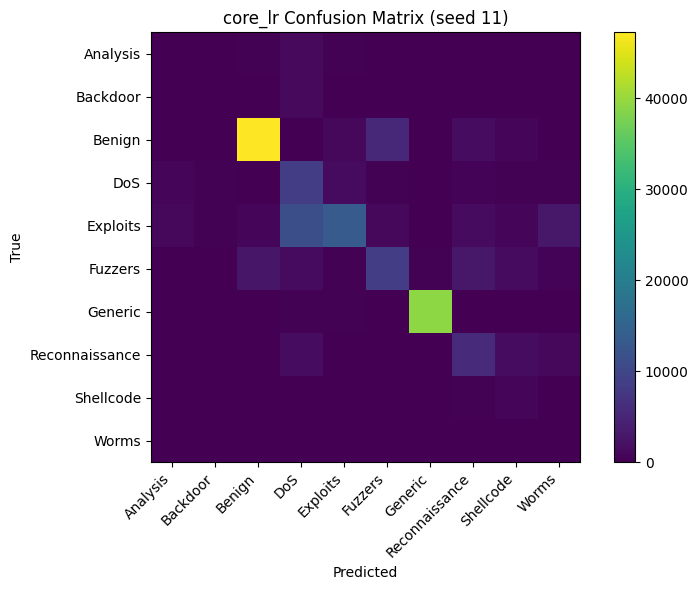

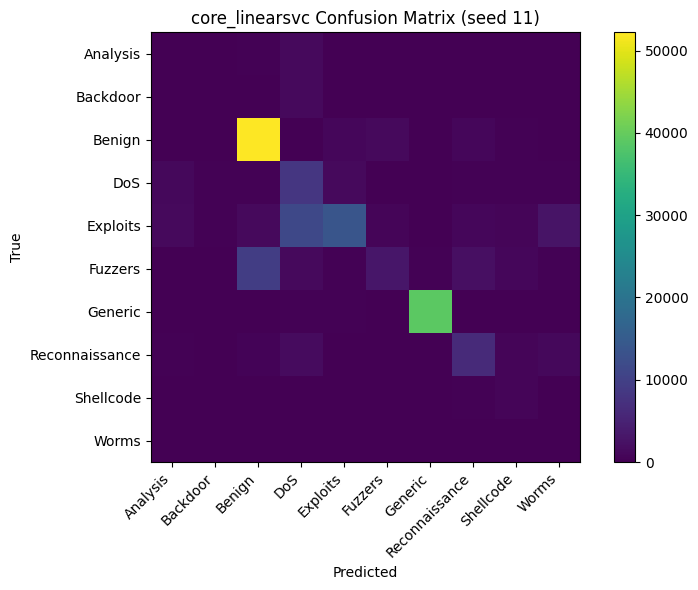

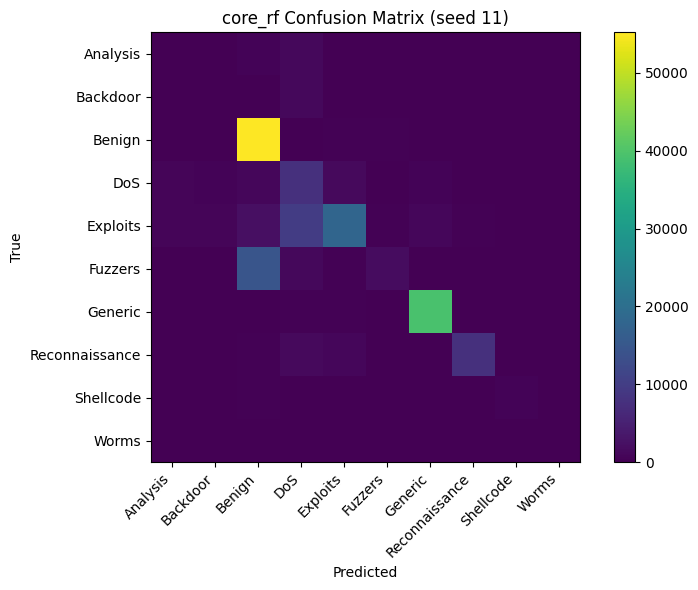

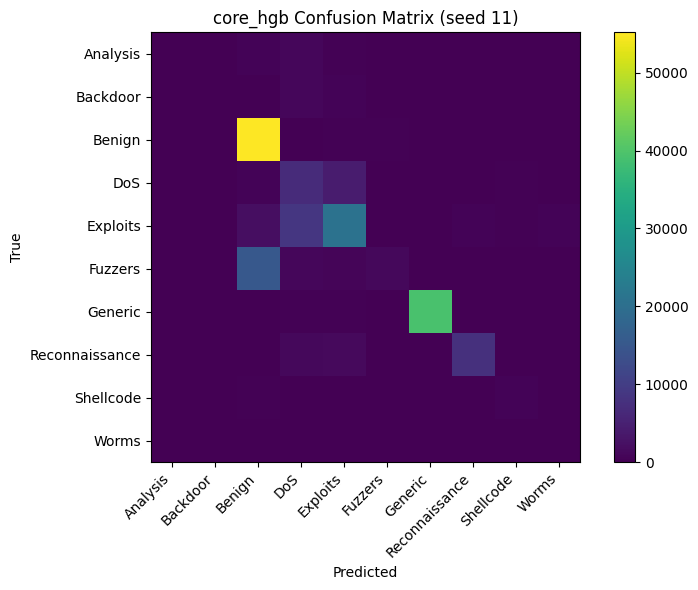

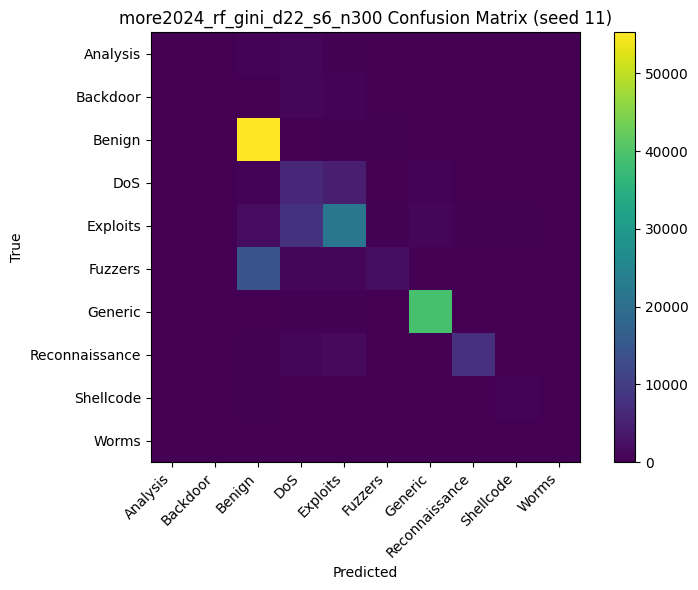

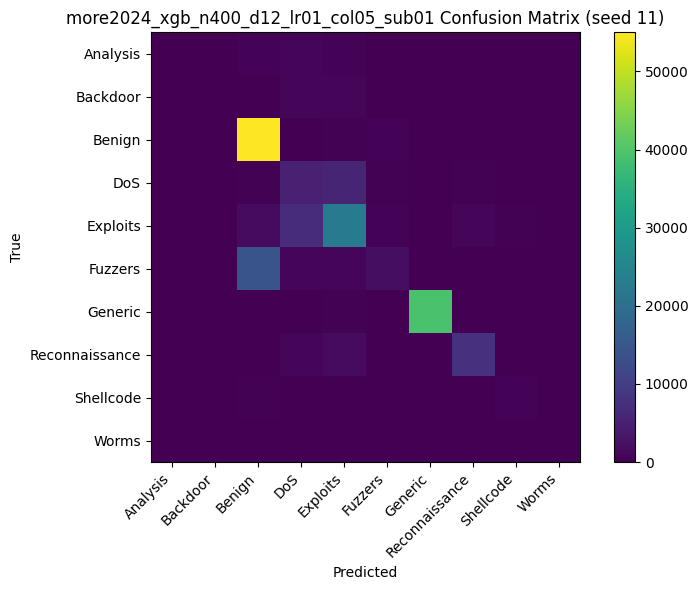

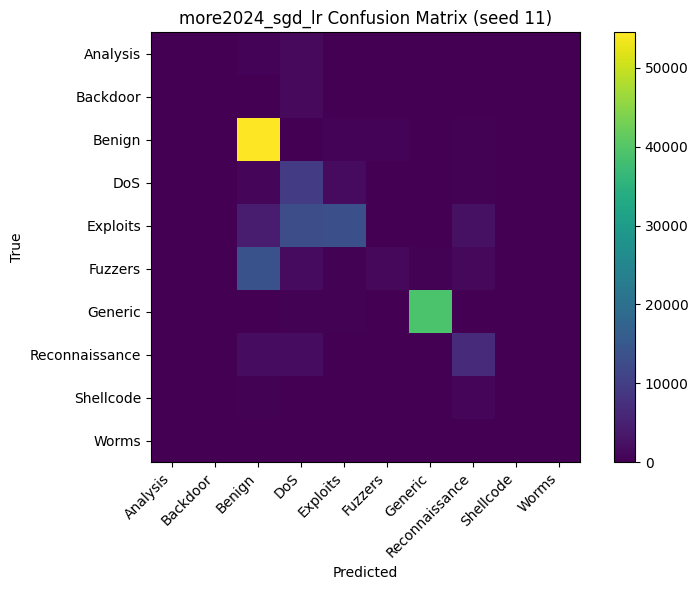

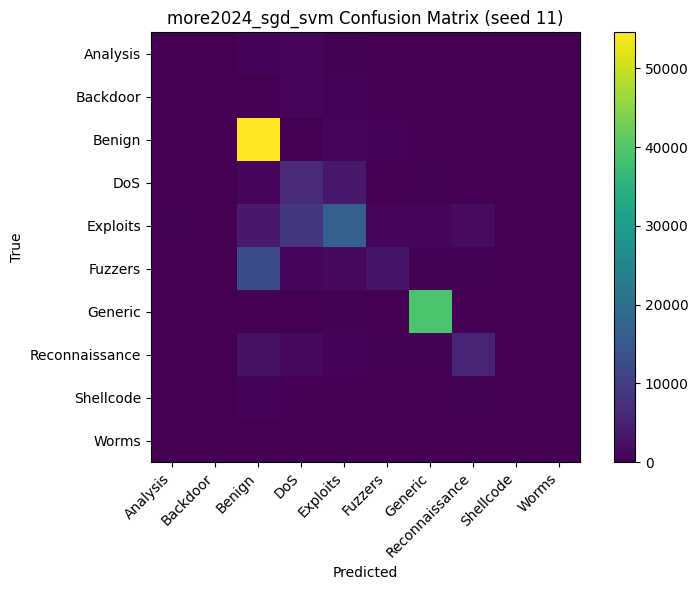

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this wa

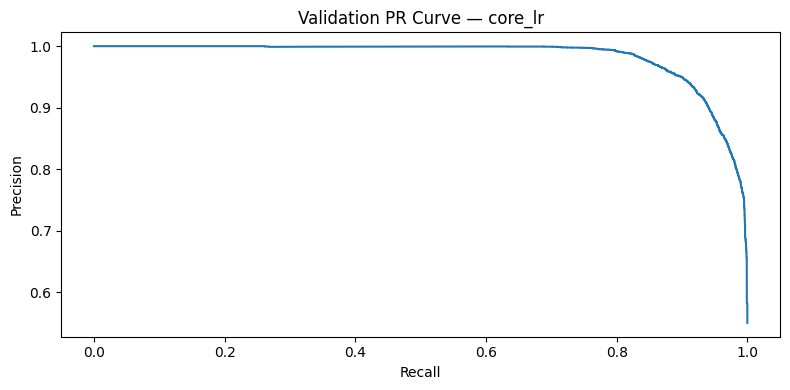

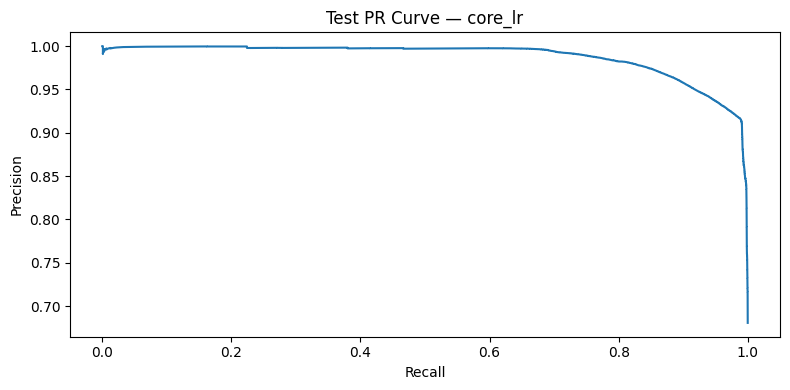

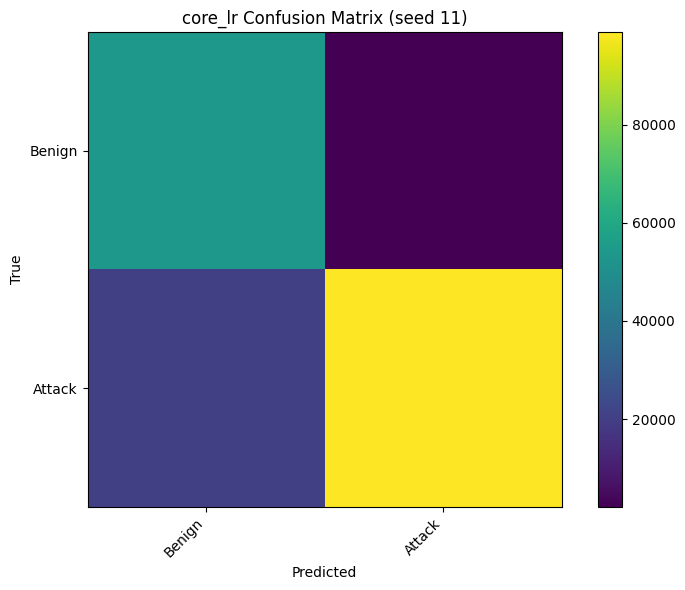

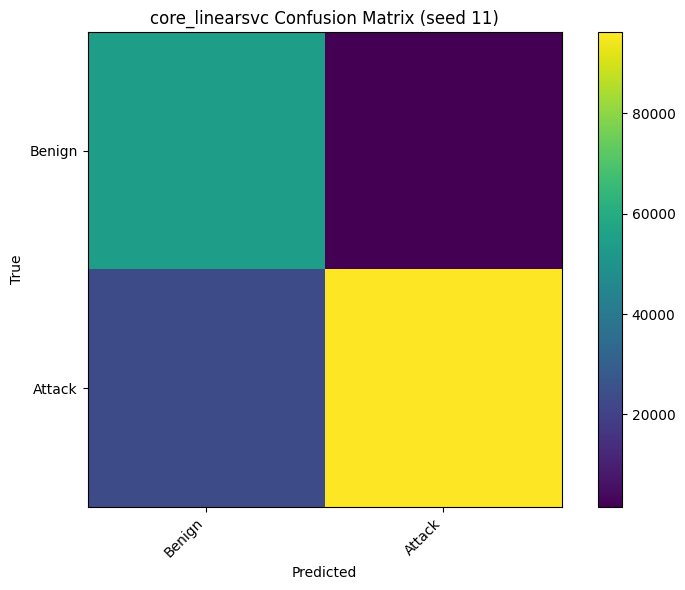

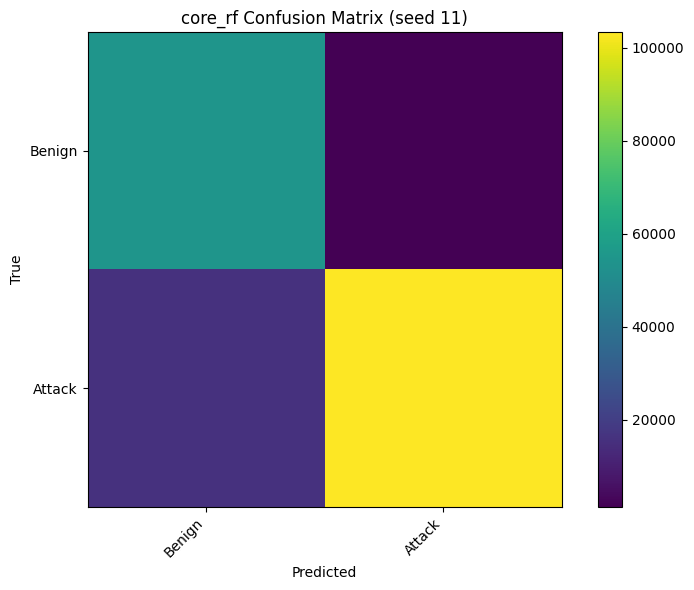

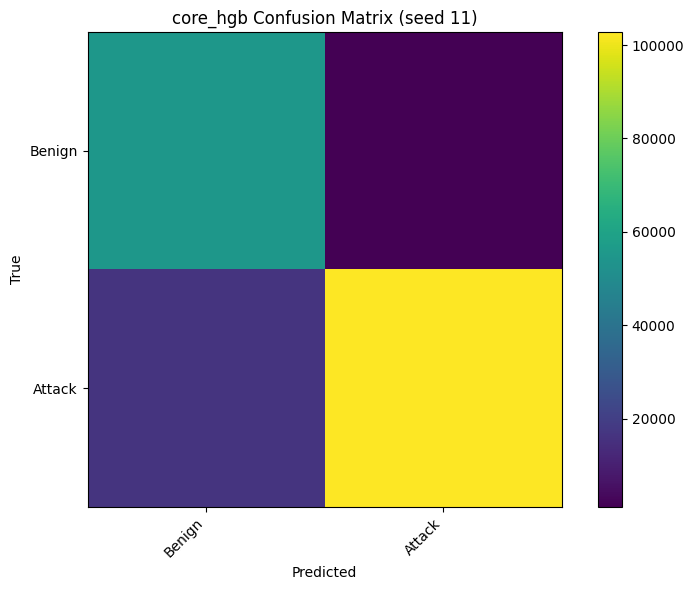

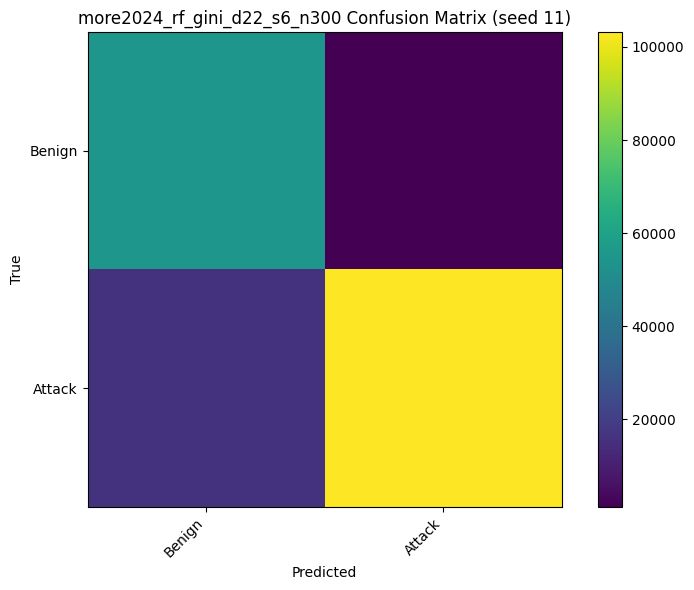

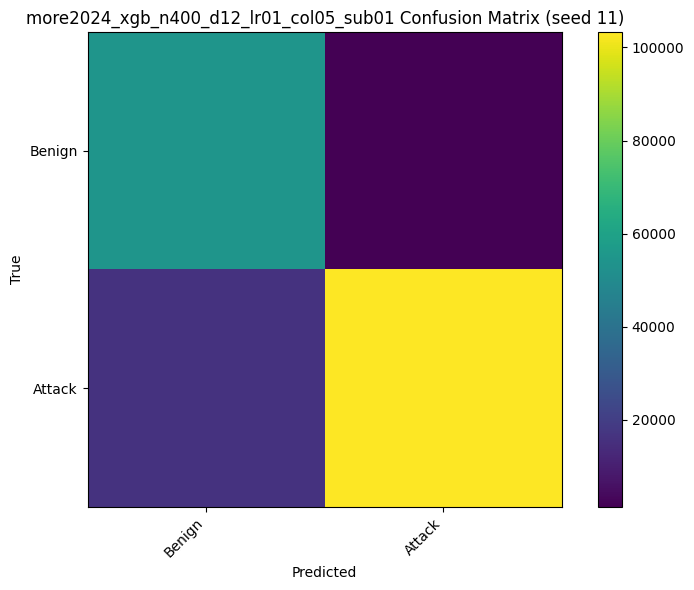

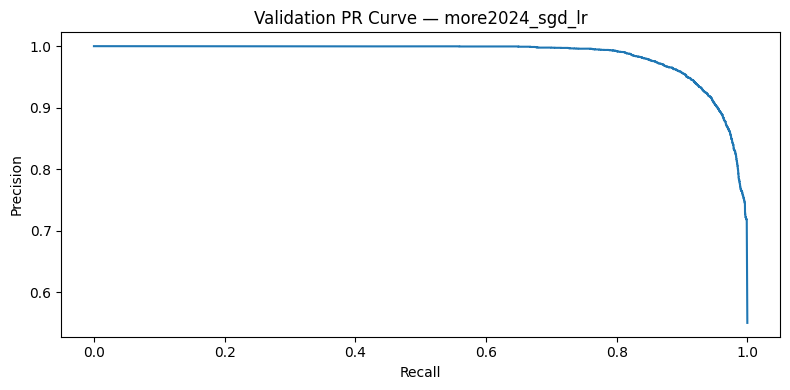

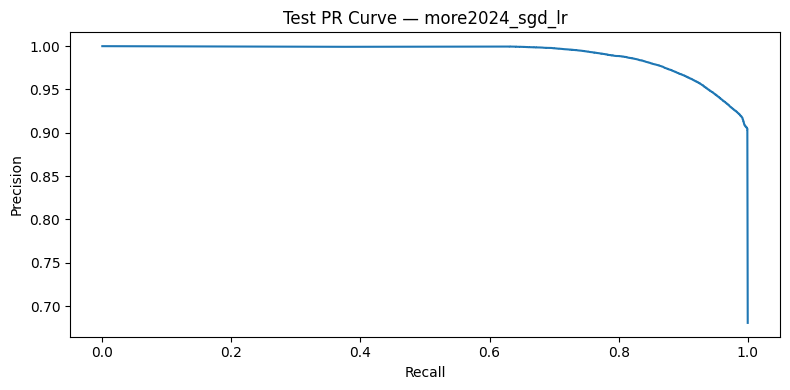

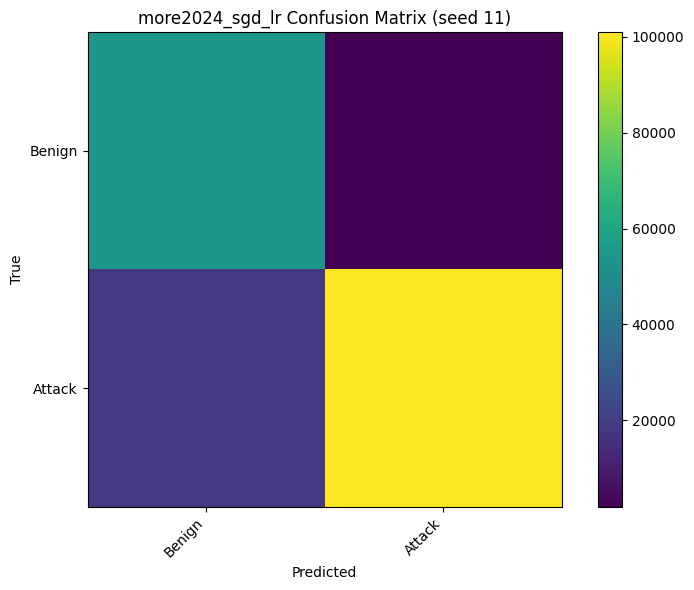

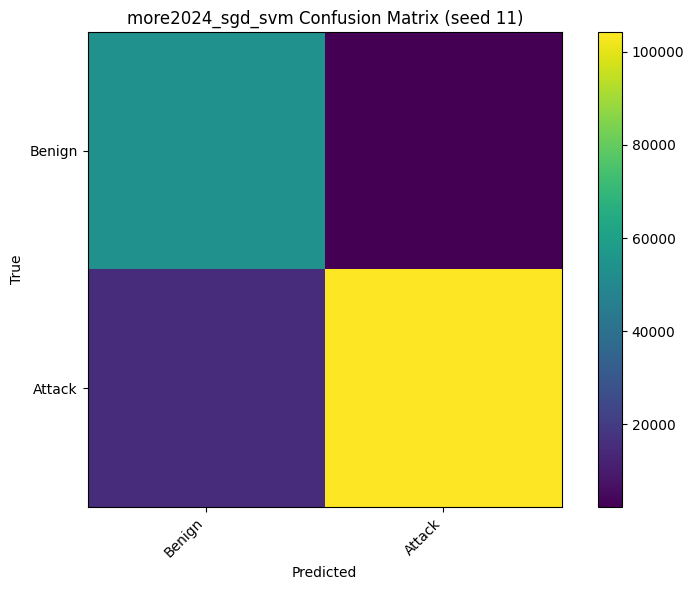

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [8]:
unsw_mc_runs, unsw_mc_summary, unsw_mc_support = run_task(unsw_mc, UNSW_OUT / "multiclass")
unsw_bin_runs, unsw_bin_summary, unsw_bin_support = run_task(unsw_bin, UNSW_OUT / "binary")
syn_mc_runs, syn_mc_summary, syn_mc_support = run_task(syn_mc, SYN_OUT / "multiclass")
syn_bin_runs, syn_bin_summary, syn_bin_support = run_task(syn_bin, SYN_OUT / "binary")

print("UNSW multiclass summary")
display(unsw_mc_summary)

print("UNSW binary summary")
display(unsw_bin_summary)

print("Synthetic multiclass summary")
display(syn_mc_summary)

print("Synthetic binary summary")
display(syn_bin_summary)


## Synthetic Multiclass Split Handling

Recovery cell for low-support class handling in the synthetic multiclass split.


In [11]:
from sklearn.model_selection import StratifiedShuffleSplit as _OriginalStratifiedShuffleSplit
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

def safe_train_val_split_indices(X, y, train_size=0.85, seed=42):
    """
    Stratified split normally fails when any class has only 1 sample.
    This version keeps singleton classes in training and stratifies the rest.
    """

    y_series = pd.Series(y)
    counts = y_series.value_counts()

    singleton_labels = set(counts[counts < 2].index)

    singleton_idx = np.array(
        [i for i, label in enumerate(y) if label in singleton_labels],
        dtype=int
    )

    normal_idx = np.array(
        [i for i, label in enumerate(y) if label not in singleton_labels],
        dtype=int
    )

    if len(normal_idx) == 0:
        all_idx = np.arange(len(y))
        train_idx, val_idx = train_test_split(
            all_idx,
            train_size=train_size,
            random_state=seed,
            shuffle=True
        )
        return train_idx, val_idx

    y_normal = np.array(y)[normal_idx]

    train_normal_idx, val_idx = train_test_split(
        normal_idx,
        train_size=train_size,
        random_state=seed,
        shuffle=True,
        stratify=y_normal
    )

    train_idx = np.concatenate([train_normal_idx, singleton_idx])

    return train_idx, val_idx


class SafeStratifiedShuffleSplit:
    def __init__(self, n_splits=1, train_size=None, test_size=None, random_state=None):
        self.n_splits = n_splits
        self.train_size = train_size
        self.test_size = test_size
        self.random_state = random_state

    def split(self, X, y, groups=None):
        for i in range(self.n_splits):
            seed = self.random_state if self.random_state is not None else 42
            train_idx, val_idx = safe_train_val_split_indices(
                X,
                y,
                train_size=self.train_size,
                seed=seed + i
            )
            yield train_idx, val_idx


StratifiedShuffleSplit = SafeStratifiedShuffleSplit

print("Safe split patch applied. Now rerunning only the unfinished synthetic experiments.")


Safe split patch applied. Now rerunning only the unfinished synthetic experiments.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


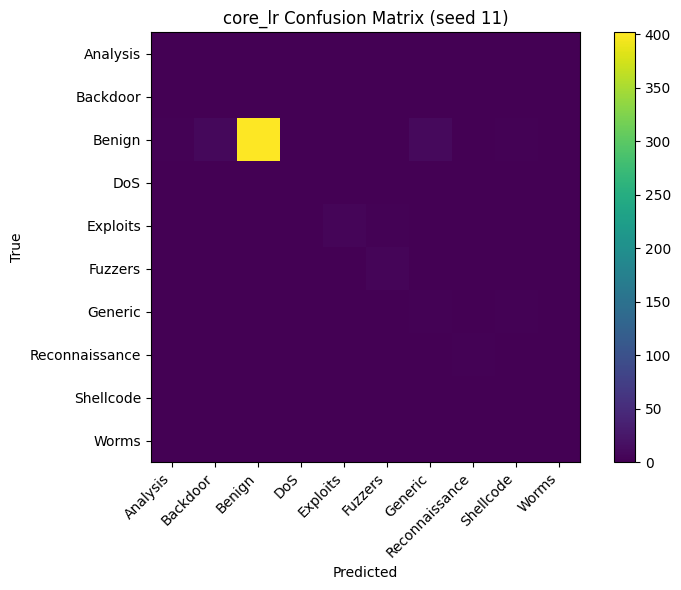

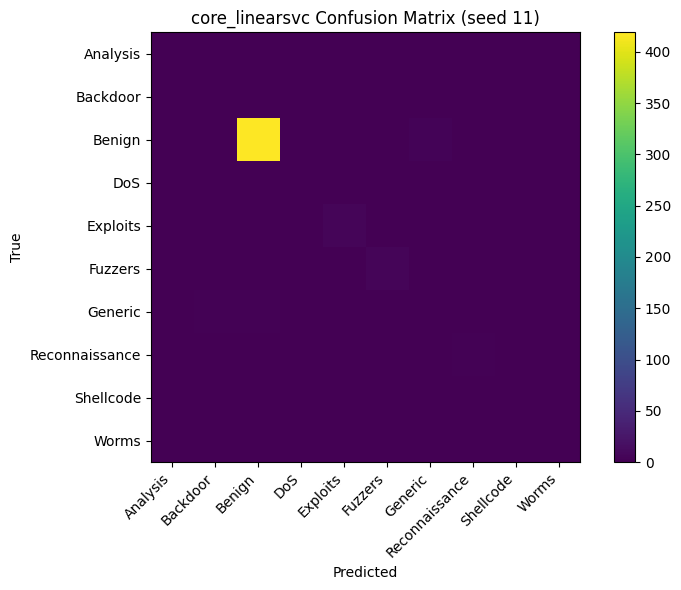

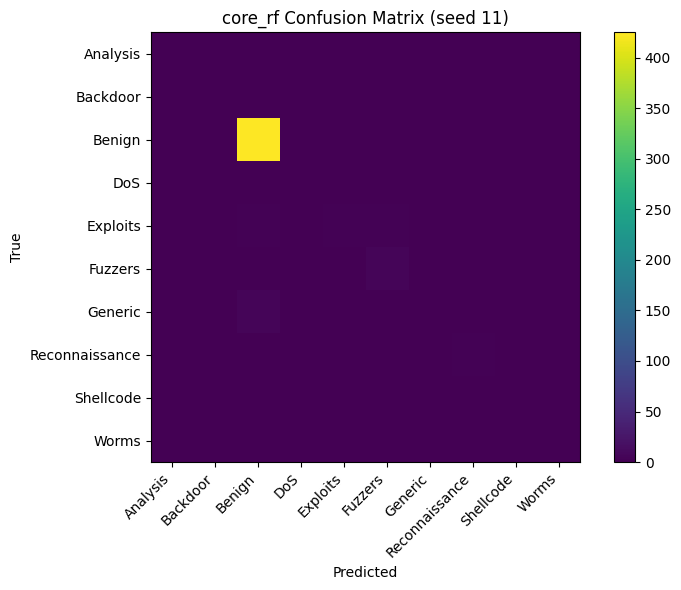

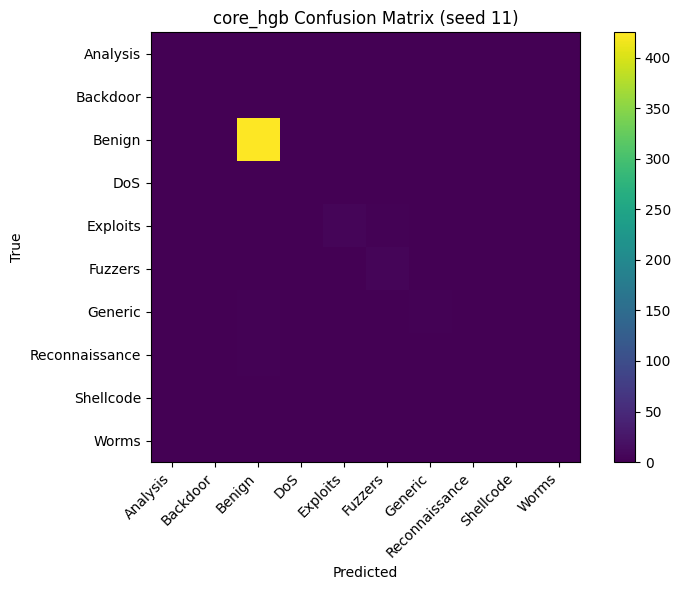

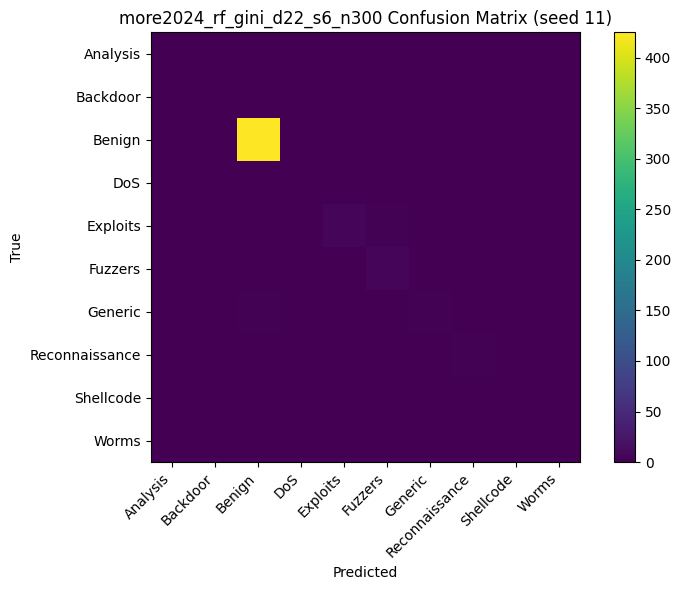

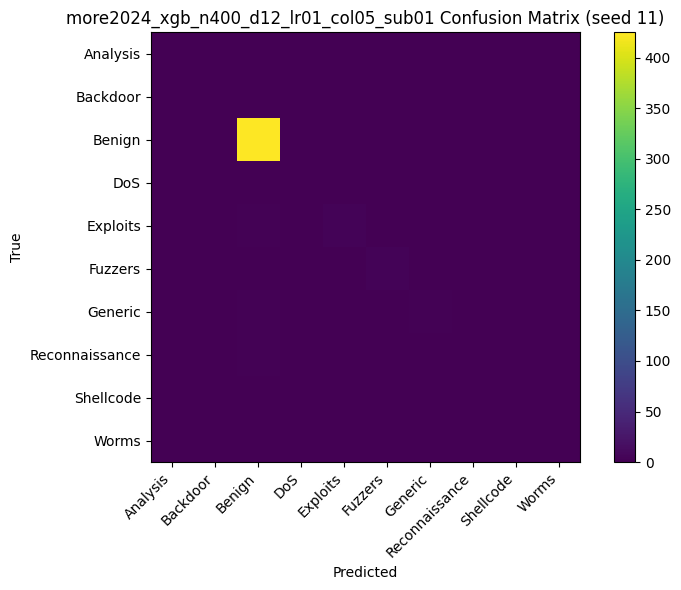

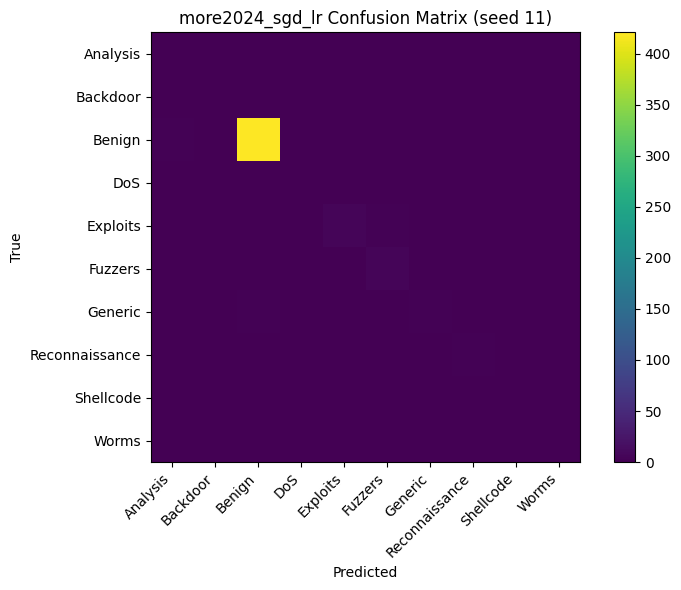

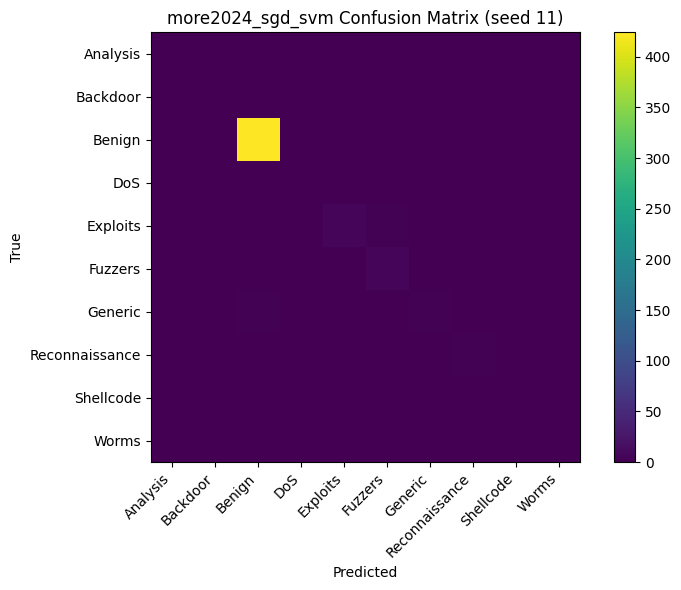

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

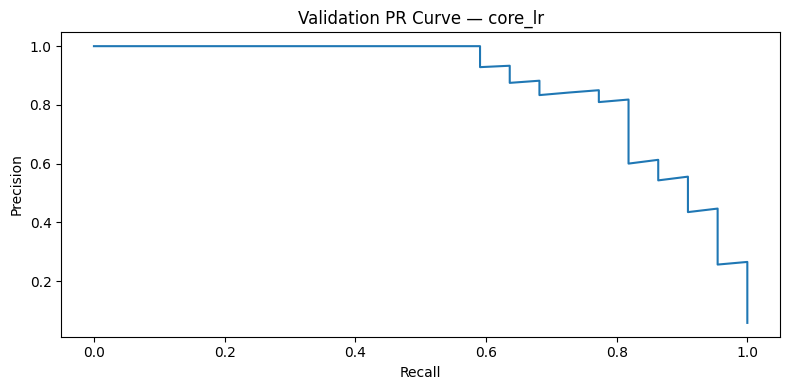

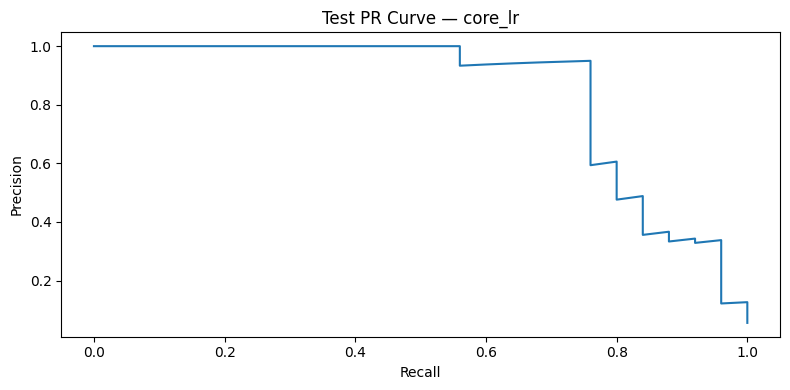

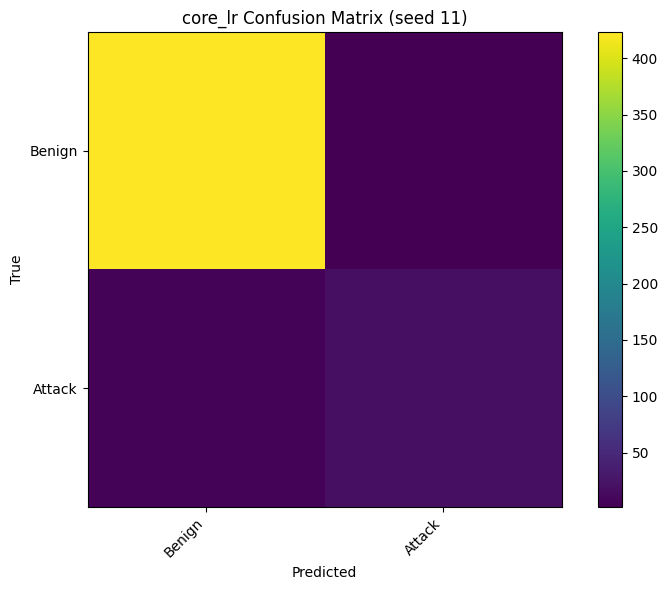

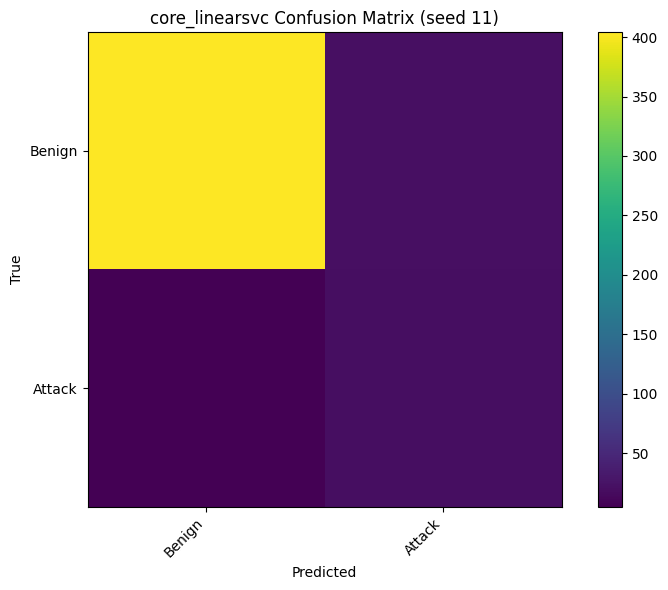

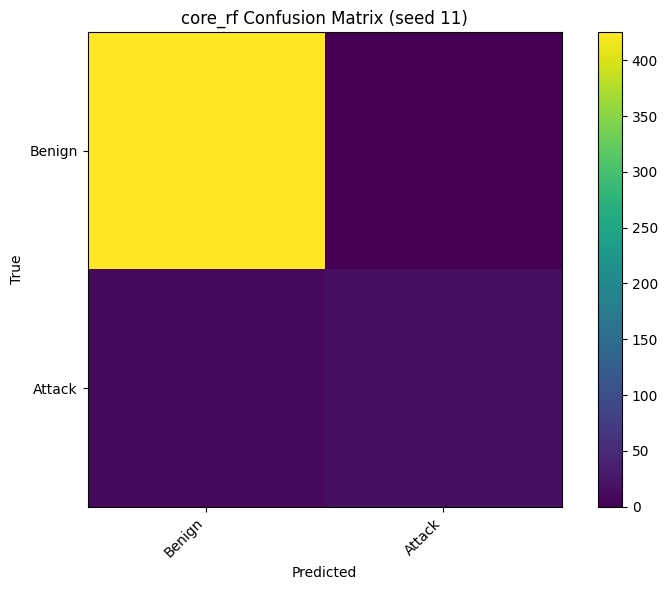

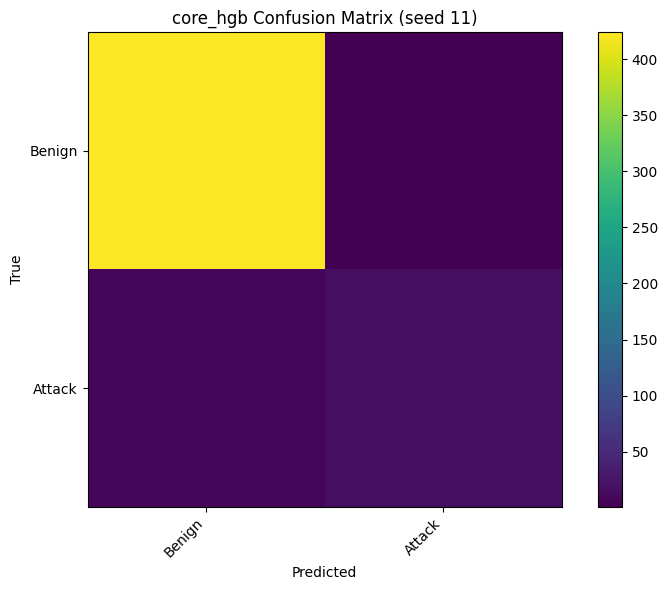

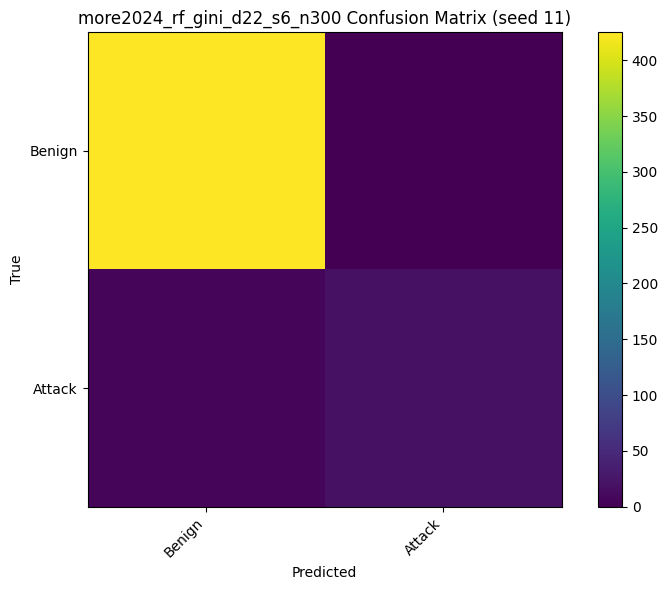

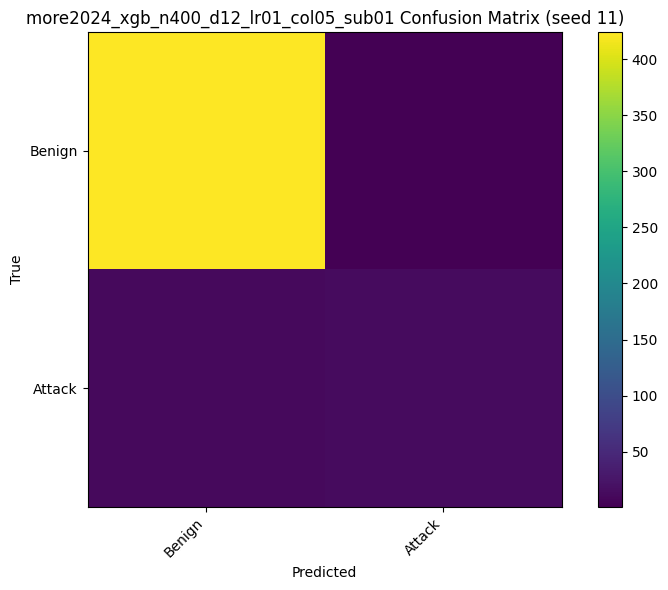

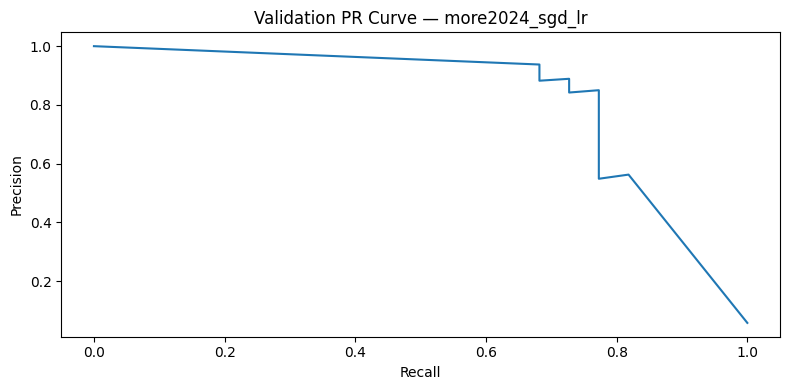

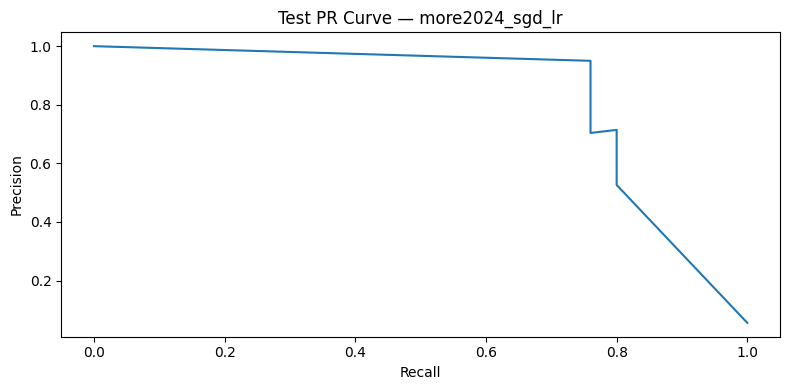

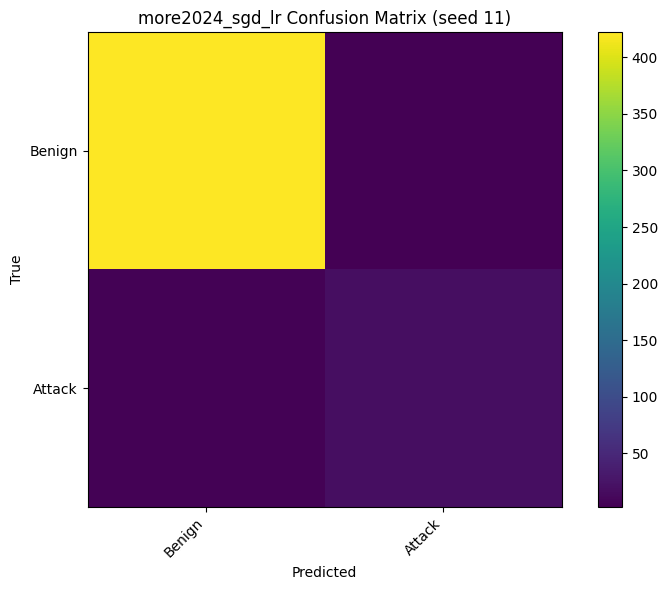

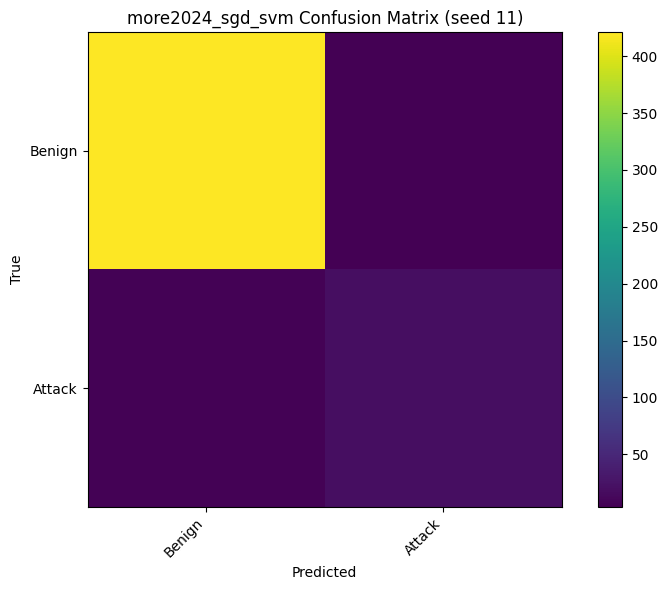

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Synthetic multiclass summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std
4,more2024_rf_gini_d22_s6_n300,0.979111,0.002534,0.490556,0.027742,0.467810,0.020662,0.972736,0.004117
5,more2024_sgd_lr,0.971111,0.003849,0.435519,0.028556,0.454484,0.016465,0.969911,0.003599
3,core_rf,0.972444,0.001988,0.431718,0.010666,0.418095,0.012778,0.962469,0.002613
0,core_hgb,0.974667,0.003718,0.418386,0.018264,0.413525,0.022508,0.967060,0.004337
6,more2024_sgd_svm,0.969778,0.004869,0.417779,0.021597,0.435721,0.016835,0.968040,0.003587
1,core_linearsvc,0.959111,0.003718,0.417079,0.021119,0.432449,0.022948,0.962627,0.002909
2,core_lr,0.924444,0.004969,0.415574,0.009405,0.473261,0.018608,0.944327,0.003061
7,more2024_xgb_n400_d12_lr01_col05_sub01,0.968889,0.004157,0.332445,0.031279,0.294239,0.029310,0.961123,0.005027


Synthetic binary summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
4,more2024_rf_gini_d22_s6_n300,0.988000,0.001217,1.000000,0.000000,0.784,0.021909,0.878788,0.013831
5,more2024_sgd_lr,0.981778,0.002897,0.883676,0.047334,0.776,0.021909,0.825804,0.025033
2,core_lr,0.981333,0.003370,0.932857,0.042338,0.720,0.089443,0.808131,0.051036
6,more2024_sgd_svm,0.979556,0.001859,0.856842,0.032712,0.760,0.000000,0.805288,0.014357
3,core_rf,0.978667,0.001217,1.000000,0.000000,0.616,0.021909,0.762195,0.016699
0,core_hgb,0.977778,0.002722,0.943791,0.055575,0.640,0.028284,0.761960,0.027555
7,more2024_xgb_n400_d12_lr01_col05_sub01,0.973333,0.002722,0.884248,0.031291,0.600,0.063246,0.712805,0.041602
1,core_linearsvc,0.948000,0.003718,0.520385,0.021233,0.832,0.017889,0.640216,0.020802


In [12]:
syn_mc_runs, syn_mc_summary, syn_mc_support = run_task(
    syn_mc,
    SYN_OUT / "multiclass"
)

syn_bin_runs, syn_bin_summary, syn_bin_support = run_task(
    syn_bin,
    SYN_OUT / "binary"
)

print("Synthetic multiclass summary")
display(syn_mc_summary)

print("Synthetic binary summary")
display(syn_bin_summary)


## Comparison Tables


In [13]:
def tag_model_family(model_name):
    if model_name.startswith("core_"):
        return "core"
    if model_name.startswith("more2024_"):
        return "paper_inspired_more2024"
    return "other"

unsw_mc_cmp = unsw_mc_summary.copy()
unsw_mc_cmp["dataset"] = "UNSW-NB15"
unsw_mc_cmp["task"] = "multiclass"
unsw_mc_cmp["family"] = unsw_mc_cmp["model"].map(tag_model_family)

unsw_bin_cmp = unsw_bin_summary.copy()
unsw_bin_cmp["dataset"] = "UNSW-NB15"
unsw_bin_cmp["task"] = "binary"
unsw_bin_cmp["family"] = unsw_bin_cmp["model"].map(tag_model_family)

syn_mc_cmp = syn_mc_summary.copy()
syn_mc_cmp["dataset"] = "Synthetic IPv6"
syn_mc_cmp["task"] = "multiclass"
syn_mc_cmp["family"] = syn_mc_cmp["model"].map(tag_model_family)

syn_bin_cmp = syn_bin_summary.copy()
syn_bin_cmp["dataset"] = "Synthetic IPv6"
syn_bin_cmp["task"] = "binary"
syn_bin_cmp["family"] = syn_bin_cmp["model"].map(tag_model_family)

within_all = pd.concat([unsw_mc_cmp, unsw_bin_cmp, syn_mc_cmp, syn_bin_cmp], axis=0, ignore_index=True)
within_all.to_csv(COMBINED_OUT / "benchmark_comparison_all.csv", index=False)

best_rows = []
for name, df, task in [
    ("UNSW-NB15", unsw_mc_summary, "multiclass"),
    ("UNSW-NB15", unsw_bin_summary, "binary"),
    ("Synthetic IPv6", syn_mc_summary, "multiclass"),
    ("Synthetic IPv6", syn_bin_summary, "binary"),
]:
    if task == "multiclass":
        row = df.sort_values("macro_f1_mean", ascending=False).iloc[0].to_dict()
    else:
        row = df.sort_values("f1_mean", ascending=False).iloc[0].to_dict()
    row["dataset"] = name
    row["task"] = task
    best_rows.append(row)

best_df = pd.DataFrame(best_rows)
best_df.to_csv(COMBINED_OUT / "best_model_per_dataset_task.csv", index=False)

display(within_all.head(20))
display(best_df)


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std,dataset,task,family,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,core_rf,0.744750,0.000366,0.496084,0.007669,0.490040,0.004268,0.719706,0.000463,UNSW-NB15,multiclass,core,NaN,NaN,NaN,NaN,NaN,NaN
1,more2024_xgb_n400_d12_lr01_col05_sub01,0.758557,0.000826,0.470764,0.005806,0.461466,0.004075,0.727018,0.000740,UNSW-NB15,multiclass,paper_inspired_more2024,NaN,NaN,NaN,NaN,NaN,NaN
2,more2024_rf_gini_d22_s6_n300,0.755835,0.001048,0.462199,0.009797,0.458339,0.005510,0.723570,0.001486,UNSW-NB15,multiclass,paper_inspired_more2024,NaN,NaN,NaN,NaN,NaN,NaN
3,core_hgb,0.744164,0.005509,0.442768,0.007183,0.481790,0.015513,0.712701,0.003471,UNSW-NB15,multiclass,core,NaN,NaN,NaN,NaN,NaN,NaN
4,core_lr,0.703985,0.001705,0.421014,0.002532,0.550139,0.002691,0.724090,0.000747,UNSW-NB15,multiclass,core,NaN,NaN,NaN,NaN,NaN,NaN
5,core_linearsvc,0.705372,0.000749,0.408134,0.000873,0.516674,0.005821,0.701601,0.000344,UNSW-NB15,multiclass,core,NaN,NaN,NaN,NaN,NaN,NaN
6,more2024_sgd_svm,0.709583,0.010347,0.358952,0.015279,0.368722,0.009085,0.677780,0.012277,UNSW-NB15,multiclass,paper_inspired_more2024,NaN,NaN,NaN,NaN,NaN,NaN
7,more2024_sgd_lr,0.715695,0.010372,0.355731,0.022507,0.362447,0.020483,0.677972,0.016386,UNSW-NB15,multiclass,paper_inspired_more2024,NaN,NaN,NaN,NaN,NaN,NaN
8,core_rf,0.901374,0.000528,NaN,NaN,NaN,NaN,NaN,NaN,UNSW-NB15,binary,core,0.987406,0.000281,0.866142,0.000670,0.922807,0.000434
9,more2024_rf_gini_d22_s6_n300,0.900959,0.000498,NaN,NaN,NaN,NaN,NaN,NaN,UNSW-NB15,binary,paper_inspired_more2024,0.987976,0.000279,0.865012,0.000828,0.922414,0.000426


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,weighted_f1_mean,weighted_f1_std,dataset,task,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,core_rf,0.744750,0.000366,0.496084,0.007669,0.49004,0.004268,0.719706,0.000463,UNSW-NB15,multiclass,NaN,NaN,NaN,NaN,NaN,NaN
1,core_rf,0.901374,0.000528,NaN,NaN,NaN,NaN,NaN,NaN,UNSW-NB15,binary,0.987406,0.000281,0.866142,0.000670,0.922807,0.000434
2,more2024_rf_gini_d22_s6_n300,0.979111,0.002534,0.490556,0.027742,0.46781,0.020662,0.972736,0.004117,Synthetic IPv6,multiclass,NaN,NaN,NaN,NaN,NaN,NaN
3,more2024_rf_gini_d22_s6_n300,0.988000,0.001217,NaN,NaN,NaN,NaN,NaN,NaN,Synthetic IPv6,binary,1.000000,0.000000,0.784000,0.021909,0.878788,0.013831


## Artifact Dashboard


In [14]:
def list_folder(folder: Path):
    return sorted([p.name for p in folder.glob("*")])

dashboard = {
    "unsw_multiclass": {
        "tables": list_folder(UNSW_OUT / "multiclass" / "tables"),
        "figures": list_folder(UNSW_OUT / "multiclass" / "figures"),
        "metrics": list_folder(UNSW_OUT / "multiclass" / "metrics"),
        "reports": list_folder(UNSW_OUT / "multiclass" / "reports"),
    },
    "unsw_binary": {
        "tables": list_folder(UNSW_OUT / "binary" / "tables"),
        "figures": list_folder(UNSW_OUT / "binary" / "figures"),
        "metrics": list_folder(UNSW_OUT / "binary" / "metrics"),
        "reports": list_folder(UNSW_OUT / "binary" / "reports"),
    },
    "synthetic_multiclass": {
        "tables": list_folder(SYN_OUT / "multiclass" / "tables"),
        "figures": list_folder(SYN_OUT / "multiclass" / "figures"),
        "metrics": list_folder(SYN_OUT / "multiclass" / "metrics"),
        "reports": list_folder(SYN_OUT / "multiclass" / "reports"),
    },
    "synthetic_binary": {
        "tables": list_folder(SYN_OUT / "binary" / "tables"),
        "figures": list_folder(SYN_OUT / "binary" / "figures"),
        "metrics": list_folder(SYN_OUT / "binary" / "metrics"),
        "reports": list_folder(SYN_OUT / "binary" / "reports"),
    },
    "combined": {
        "files": list_folder(COMBINED_OUT),
    }
}

save_json(dashboard, COMBINED_OUT / "artefact_dashboard.json")
dashboard


{'unsw_multiclass': {'tables': ['all_runs.csv',
   'core_hgb_confusion_matrix_seed_11.csv',
   'core_linearsvc_confusion_matrix_seed_11.csv',
   'core_lr_confusion_matrix_seed_11.csv',
   'core_rf_confusion_matrix_seed_11.csv',
   'more2024_rf_gini_d22_s6_n300_confusion_matrix_seed_11.csv',
   'more2024_sgd_lr_confusion_matrix_seed_11.csv',
   'more2024_sgd_svm_confusion_matrix_seed_11.csv',
   'more2024_xgb_n400_d12_lr01_col05_sub01_confusion_matrix_seed_11.csv',
   'summary_mean_std.csv',
   'test_support_flags.csv'],
  'figures': ['core_hgb_confusion_seed_11.png',
   'core_linearsvc_confusion_seed_11.png',
   'core_lr_confusion_seed_11.png',
   'core_rf_confusion_seed_11.png',
   'more2024_rf_gini_d22_s6_n300_confusion_seed_11.png',
   'more2024_sgd_lr_confusion_seed_11.png',
   'more2024_sgd_svm_confusion_seed_11.png',
   'more2024_xgb_n400_d12_lr01_col05_sub01_confusion_seed_11.png',
   'unsw_attackcat_distribution_train.png'],
  'metrics': ['manifest.json',
   'paper_sgd_tuning_s

## Result Summary Export


In [15]:
lines = []
lines.append("# Benchmark Results Summary")
lines.append("")
lines.append("## Completed Runs")
lines.append("- Established benchmark baselines on UNSW-NB15 and Synthetic IPv6.")
lines.append("- Kept the fixed evaluation logic consistent across both datasets.")
lines.append("- Exported seed-wise runs, mean±std summaries, unstable-class support checks, reports, and confusion matrices.")
lines.append("- Added paper-inspired benchmark replications based on More et al. (2024).")
lines.append("")

lines.append("## Files to cite in writing")
lines.append("- `combined/benchmark_comparison_all.csv`")
lines.append("- `combined/best_model_per_dataset_task.csv`")
lines.append("- `unsw/multiclass/tables/summary_mean_std.csv`")
lines.append("- `unsw/binary/tables/summary_mean_std.csv`")
lines.append("- `synthetic/multiclass/tables/summary_mean_std.csv`")
lines.append("- `synthetic/binary/tables/summary_mean_std.csv`")
lines.append("")

lines.append("## Interpretation reminders")
lines.append("- Macro-F1 is the main metric for multiclass because of imbalance.")
lines.append("- Binary LR thresholding is included because the supervisor specifically requested PR-curve based threshold selection.")
lines.append("- Synthetic remains the project-specific evaluation dataset, but UNSW baselines are needed to justify later CNN comparisons.")
lines.append("- Paper-inspired replications help identify whether accuracy drops come from the dataset, the evaluation design, or the model family.")
lines.append("")

save_text("\n".join(lines), COMBINED_OUT / "benchmark_results_summary.md")
print("Saved:", (COMBINED_OUT / "benchmark_results_summary.md").resolve())


Saved: /kaggle/working/benchmark_artifacts/combined/benchmark_results_summary.md
